# Weighted vs unweighted weak PDE regression (GLS test)

This notebook compares standard weak-form PDE regression with and without
spatiotemporal weighting based on a variance field.

We consider a simple 1D diffusion equation

$$
u_t = \nu\,u_{xx}
$$

on a periodic domain and generate synthetic data $u(x,t)$. We add
heteroskedastic noise to the time derivative $u_t$, build a weak
library, and then compare:

- unweighted regression (OLS in weak space),
- weighted regression using the `WeightedWeakPDELibrary`, i.e. GLS with
  covariance implied by the variance field.

In [1]:
# %% Imports

import numpy as np
import matplotlib.pyplot as plt


import pysindy as ps
from pysindy.feature_library import WeakPDELibrary, WeightedWeakPDELibrary  # custom GLS version


## 1. Synthetic test problem: scalar linear ODE

Consider
$$
\frac{du}{dt} = \lambda u, \qquad \lambda = -0.5.
$$

The analytic solution with initial condition $u(0) = u_0$ is
$$
u(t) = u_0 e^{\lambda t}.
$$

SINDy is given noisy observations of $u(t)$. The weak library integrates in
time and constructs weak derivatives. The goal is to identify the correct
equation
$$
u_t = \lambda u
$$
from the candidate features $[u, u^2]$ in a polynomial library of degree 2.

In [2]:
# %% 1. Generate clean data

# true parameter
lam_true = -0.5

# time grid
T_final = 5.0
Nt = 400
t_eval = np.linspace(0.0, T_final, Nt)

# initial condition and analytic solution
u0 = 1.0
u_clean = u0 * np.exp(lam_true * t_eval)        # shape (Nt,)
u_clean = u_clean[:, None]                      # shape (Nt, 1) for SINDy


## 2. Heteroskedastic noise and variance field

Define a time-dependent noise variance
$$
\sigma(t)^2 = \sigma_0^2 (1 + \alpha t^2),
$$
and generate noisy observations
$$
u^{\text{noisy}}(t_i) = u(t_i) + \eta_i, \quad \eta_i \sim \mathcal{N}(0,\sigma(t_i)^2).
$$

The same variance field $\sigma^2(t)$ is passed to `WeightedWeakPDELibrary`
as `spatiotemporal_weights`.

In [3]:
# %% 2. Define heteroskedastic noise model

sigma0 = 0.02     # base noise std
alpha = 1.5       # heteroskedasticity strength

sigma_t = sigma0 * np.sqrt(1.0 + alpha * t_eval**2)  # std over time, shape (Nt,)
sigma2_t = sigma_t**2                                # variance


def add_noise(u_clean, rng):
    """Add heteroskedastic noise to u_clean(t)."""
    # make sigma_t 2D so it broadcasts with (Nt, 1)
    sigma_2d = sigma_t[:, None]        # shape (Nt, 1)
    noise = rng.normal(loc=0.0, scale=sigma_2d, size=u_clean.shape)
    return u_clean + noise


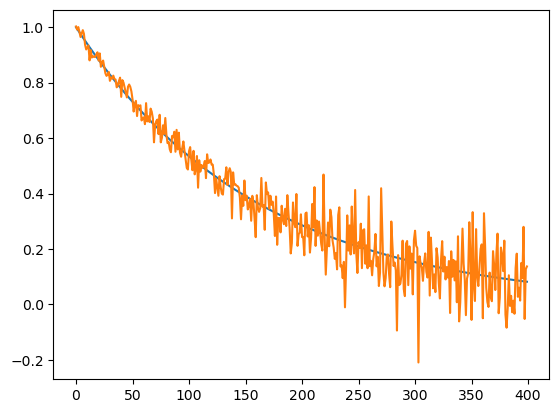

In [ ]:
rng = np.random.default_rng(0)

U_noisy = add_noise(u_clean, rng)  # shape (Nt, 1)
plt.plot(u_clean)
plt.plot(U_noisy)


## 3. Weak libraries (unweighted vs weighted)

The spatiotemporal grid is only time here, so
$$
X_T = t_{\text{eval}} \in \mathbb{R}^{N_t \times 1}.
$$
The variance field is passed with the same shape,
$$
\text{spatiotemporal\_weights} \in \mathbb{R}^{N_t \times 1},
$$
interpreted as a variance $\sigma^2(t_i)$ at each time point.

Three libraries are constructed:

1. `weak_lib`: unweighted weak SINDy (no variance information).
2. `weighted_weak_lib`: GLS with the true variance $\sigma^2(t)$.
3. `weighted_weak_lib2`: GLS with constant weights (control).

In [5]:
# %% 3. Construct weak libraries and SINDy models

XT = t_eval[:, None]   # shape (Nt, 1)

# base polynomial library Φ(u) = [u, u^2]
base_library = ps.PolynomialLibrary(degree=1, include_bias=False)

# variance field with shape (Nt, 1)
spatiotemporal_weights = sigma2_t[:, None]

# optionally rescale the weights if needed for conditioning
# (for example, divide by mean variance)
spatiotemporal_weights_scaled = spatiotemporal_weights / np.mean(spatiotemporal_weights)

# 3.1 unweighted weak library
weak_lib = WeakPDELibrary(
    function_library=base_library,
    derivative_order=1,
    spatiotemporal_grid=XT,
    is_uniform=True,
    include_bias=False,
)

# 3.2 weighted weak library with variance-based GLS
weighted_weak_lib = WeightedWeakPDELibrary(
    function_library=base_library,
    derivative_order=1,
    spatiotemporal_grid=XT,
    spatiotemporal_weights=spatiotemporal_weights_scaled,
    is_uniform=True,
    include_bias=False,
)

# 3.3 weighted weak library with constant weights (control)
weighted_weak_lib2 = WeightedWeakPDELibrary(
    function_library=base_library,
    derivative_order=1,
    spatiotemporal_grid=XT,
    spatiotemporal_weights=np.ones_like(spatiotemporal_weights_scaled),
    is_uniform=True,
    include_bias=False,
)

# Optimizers: use bagged STLSQ for robustness
opt1 = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.1),
                            bagging=True, n_models=100)
opt2 = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.1),
                            bagging=True, n_models=100)
opt3 = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.1),
                            bagging=True, n_models=100)

# SINDy models corresponding to the three libraries
model_weak      = ps.SINDy(feature_library=weak_lib,          optimizer=opt1)
model_weighted  = ps.SINDy(feature_library=weighted_weak_lib, optimizer=opt2)
model_weighted2 = ps.SINDy(feature_library=weighted_weak_lib2,optimizer=opt3)


/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/feature_library/weak_pde_library.py:177: UserWarning: is_uniform and periodic have been deprecated.in favor of differetiation_method and diff_kwargs.
  warnings.warn(


## 4. Single realisation: fit and inspect models

Fit all three models on a single noisy trajectory and compare the identified
coefficients with the true value $\lambda^\star = -0.5$.

The polynomial library with degree 2 and a single state yields features
$$
\Phi(u) = [u, u^2],
$$
so the true coefficient vector is $[\lambda^\star, 0]$.

In [6]:
# %% 4. Fit once and inspect coefficients

rng = np.random.default_rng(0)

U_noisy = add_noise(u_clean, rng)  # shape (Nt, 1)

model_weak.fit(U_noisy, t=t_eval)
model_weighted.fit(U_noisy, t=t_eval)
model_weighted2.fit(U_noisy, t=t_eval)

print("Unweighted weak SINDy model:")
model_weak.print()

print("\nWeighted weak SINDy (variance-based) model:")
model_weighted.print()

print("\nWeighted weak SINDy (constant weights) model:")
model_weighted2.print()


/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


Unweighted weak SINDy model:
(x0)' = -0.531 x0

Weighted weak SINDy (variance-based) model:
(x0)' = -0.503 x0

Weighted weak SINDy (constant weights) model:
(x0)' = -0.514 x0


/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


The output should show three equations of the form
$$
u_t = \xi_1 u + \xi_2 u^2.
$$

The coefficient $\xi_1$ is expected to be close to $\lambda^\star = -0.5$,
and ideally $\xi_2$ should be zero (no spurious nonlinearity).

Next, perform a Monte Carlo experiment to quantify the benefit of weighting.

In [7]:
# %% 4.1 Extract coefficients for this realisation

def extract_coefficients(model, n_features=2):
    """
    Extract coefficients for a 1D model and pad to length n_features.
    Assumes features are ordered [u, u^2, ...] in the polynomial library.
    """
    Xi = model.coefficients()   # shape (n_active_features, 1)
    xi = np.zeros(n_features)
    m = min(n_features, Xi.shape[0])
    xi[:m] = Xi[:m, 0]
    return xi

xi_weak = extract_coefficients(model_weak)
xi_weighted = extract_coefficients(model_weighted)
xi_weighted2 = extract_coefficients(model_weighted2)

print("True coefficients:       [lam_true, 0] =", [lam_true, 0.0])
print("Unweighted coefficients:             ", xi_weak)
print("Weighted (variance) coeffs:         ", xi_weighted)
print("Weighted (const) coeffs:            ", xi_weighted2)


True coefficients:       [lam_true, 0] = [-0.5, 0.0]
Unweighted coefficients:              [-0.5308179  0.       ]
Weighted (variance) coeffs:          [-0.50334789  0.        ]
Weighted (const) coeffs:             [-0.51406935  0.        ]


## 5. Monte Carlo comparison

Repeat the experiment over multiple noise realisations and record:

- the error in the linear coefficient,
  $\varepsilon^{(m)} = |\hat\lambda^{(m)} - \lambda^\star|$,
- the spurious nonlinear coefficient magnitude
  $\eta^{(m)} = |\hat\xi_2^{(m)}|$,

for each method:

- unweighted weak SINDy,
- GLS with variance field,
- GLS with constant weights.

The expectation is that:

- the variance-based GLS method reduces the error in $\hat\lambda$,
- the variance-based GLS method reduces $|\hat\xi_2|$ (fewer spurious terms),
- the constant-weight GLS behaves similarly to the unweighted case.

In [8]:
# %% 5. Monte Carlo study

n_trials = 500

err_lam_weak = []
err_lam_weighted = []
err_lam_weighted2 = []

spur_nonlin_weak = []
spur_nonlin_weighted = []
spur_nonlin_weighted2 = []

rng = np.random.default_rng(42)

for trial in range(n_trials):
    U_noisy = add_noise(u_clean, rng)

    # Use fresh optimizers for each trial to avoid reusing ensemble state
    opt1 = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.1),
                                bagging=True, n_models=100)
    opt2 = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.1),
                                bagging=True, n_models=100)
    opt3 = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.1),
                                bagging=True, n_models=100)

    model_weak      = ps.SINDy(feature_library=weak_lib,
                               optimizer=opt1)
    model_weighted  = ps.SINDy(feature_library=weighted_weak_lib,
                               optimizer=opt2)
    model_weighted2 = ps.SINDy(feature_library=weighted_weak_lib2,
                               optimizer=opt3)

    model_weak.fit(U_noisy, t=t_eval)
    model_weighted.fit(U_noisy, t=t_eval)
    model_weighted2.fit(U_noisy, t=t_eval)

    xi_w = extract_coefficients(model_weak)
    xi_wgt = extract_coefficients(model_weighted)
    xi_wgt2 = extract_coefficients(model_weighted2)

    # errors in linear coefficient
    err_lam_weak.append(abs(xi_w[0] - lam_true))
    err_lam_weighted.append(abs(xi_wgt[0] - lam_true))
    err_lam_weighted2.append(abs(xi_wgt2[0] - lam_true))

    # magnitude of nonlinear coefficient (spurious term)
    spur_nonlin_weak.append(abs(xi_w[1]))
    spur_nonlin_weighted.append(abs(xi_wgt[1]))
    spur_nonlin_weighted2.append(abs(xi_wgt2[1]))

err_lam_weak = np.array(err_lam_weak)
err_lam_weighted = np.array(err_lam_weighted)
err_lam_weighted2 = np.array(err_lam_weighted2)

spur_nonlin_weak = np.array(spur_nonlin_weak)
spur_nonlin_weighted = np.array(spur_nonlin_weighted)
spur_nonlin_weighted2 = np.array(spur_nonlin_weighted2)


/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/CloudStorage/OneDrive-PolitecnicodiMilano/Documenti/Projects/PySINDy/pysindy/utils/_axes.py:127: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/Library/

In [9]:
# %% 5.1 Summary statistics

def summary_stats(name, err, spur):
    print(f"{name}:")
    print(f"  |λ̂ - λ*| mean   = {err.mean():.3e}")
    print(f"  |λ̂ - λ*| median = {np.median(err):.3e}")
    print(f"  |ξ2| mean       = {spur.mean():.3e}")
    print(f"  |ξ2| median     = {np.median(spur):.3e}")
    print()

summary_stats("Unweighted weak", err_lam_weak, spur_nonlin_weak)
summary_stats("Weighted (variance)", err_lam_weighted, spur_nonlin_weighted)
summary_stats("Weighted (constant)", err_lam_weighted2, spur_nonlin_weighted2)


Unweighted weak:
  |λ̂ - λ*| mean   = 1.488e-02
  |λ̂ - λ*| median = 1.272e-02
  |ξ2| mean       = 0.000e+00
  |ξ2| median     = 0.000e+00

Weighted (variance):
  |λ̂ - λ*| mean   = 5.722e-03
  |λ̂ - λ*| median = 4.926e-03
  |ξ2| mean       = 0.000e+00
  |ξ2| median     = 0.000e+00

Weighted (constant):
  |λ̂ - λ*| mean   = 7.743e-03
  |λ̂ - λ*| median = 6.582e-03
  |ξ2| mean       = 0.000e+00
  |ξ2| median     = 0.000e+00



/var/folders/4s/l1d335rn5k19twqx3g8v_9140000gn/T/ipykernel_68960/1095144244.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([err_lam_weak, err_lam_weighted, err_lam_weighted2],
/var/folders/4s/l1d335rn5k19twqx3g8v_9140000gn/T/ipykernel_68960/1095144244.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([spur_nonlin_weak, spur_nonlin_weighted, spur_nonlin_weighted2],


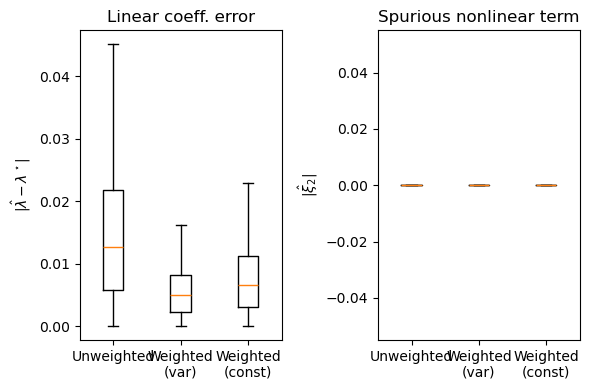

In [10]:
# %% 5.2 Visual comparison: boxplots of errors

plt.figure(figsize=(6, 4))

labels = ["Unweighted", "Weighted\n(var)", "Weighted\n(const)"]

plt.subplot(1, 2, 1)
plt.boxplot([err_lam_weak, err_lam_weighted, err_lam_weighted2],
            labels=labels, showfliers=False)
plt.ylabel(r"$|\hat{\lambda} - \lambda^\star|$")
plt.title("Linear coeff. error")

plt.subplot(1, 2, 2)
plt.boxplot([spur_nonlin_weak, spur_nonlin_weighted, spur_nonlin_weighted2],
            labels=labels, showfliers=False)
plt.ylabel(r"$|\hat{\xi}_2|$")
plt.title("Spurious nonlinear term")

plt.tight_layout()
plt.show()


## 6. Interpretation

This experiment compares three feature libraries in otherwise identical SINDy
setups:

- unweighted weak-form SINDy (ordinary least squares in weak space),
- weighted weak-form SINDy with GLS, using the true variance field
  $\sigma^2(t)$,
- weighted weak-form SINDy with constant weights (control).

If the `WeightedWeakPDELibrary` is beneficial in the heteroskedastic setting,
the results should show:

- lower mean/median error $|\hat\lambda - \lambda^\star|$ for the variance-based
  GLS method compared with the unweighted and constant-weight cases,
- smaller magnitude of the spurious nonlinear coefficient $|\hat\xi_2|$.

This provides an empirical validation that incorporating the variance field
through GLS whitening in the weak space improves robustness of the identified
model under heteroskedastic noise.